In [1]:
# ============================================================
# Imports and environment setup
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import AutoMinorLocator

# Add project source directory to path
sys.path.append('../../src')
import accrediff as ad

## Establish the bulk composition of IW-3.5 and IW-1.5

Starting from the bulk composition by enriched in refractory elements (Rubie et al., 2011), we use forward
core–mantle differentiation modeling to derive endmember compositions at two
oxygen fugacity conditions: **IW-1.5** and **IW-3.5**.

In [2]:
# ============================================================
# Publication-quality plot style (EPSL / Nature-like)
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.linewidth": 1.1,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})

# Color palette for each compositional endmember
Colors = {
    'Earth': "#1f77b4",
    'Mars': "#d62728",
    'IW-1.5': "green",
    'IW-3.5': "purple",
    'CI': "#9467bd",
}

In [3]:
# ============================================================
# Compute metal–silicate partition coefficients
# at a low-pressure reference condition (P = 0.1 GPa, T = 2000 K)
# ============================================================
P, T = 0.1, 2000  # GPa, K
kd_calc = ad.KDCalculator()
KD_Ni = kd_calc.get_KD('Ni', P, T)
KD_Si = kd_calc.get_KD('Si', P, T)
KD_O  = kd_calc.get_KD('O',  P, T)
print(f"KD_Ni = {KD_Ni:.4f},  KD_Si = {KD_Si:.6f},  KD_O = {KD_O:.6f}")

KD_Ni = 141.2538,  KD_Si = 0.000038,  KD_O = 0.217771


In [4]:
# ============================================================
# Prepare bulk composition in molar units
# Source: Bulk Earth Reference enriched in refractory elements
#         (Rubie et al., 2011)
# ============================================================
bulk_initial = ad.constants.BER       # wt% composition
Elements = ad.constants.Elements       # atomic masses (g/mol)

# Define mantle oxide and core metal species
mantle_items = ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_items = ['Fe', 'Ni', 'Si', 'O']

# Compute molar masses for oxide components
calc_custom = ad.MolarMassCalculator(mass_table=Elements)
for comp in mantle_items:
    Elements[comp] = calc_custom.molar_mass(comp)

# Convert wt% → molar amounts (mol per 100 g)
bulk_mol = {k: v / Elements[k] for k, v in bulk_initial.items() if k in Elements}

# Extract individual elemental totals for convenience
Fe_total = bulk_mol['Fe']
Ni_total = bulk_mol['Ni']
Si_total = bulk_mol['Si']
Mg_total = bulk_mol['Mg']
Al_total = bulk_mol['Al']
Ca_total = bulk_mol['Ca']

print("Molar bulk composition:")
for k, v in bulk_mol.items():
    print(f"  {k}: {v:.6f}")

Molar bulk composition:
  Si: 0.380206
  Mg: 0.395311
  Fe: 0.329991
  Al: 0.038547
  Ca: 0.028443
  Ni: 0.018351
  Co: 0.000857
  Nb: 0.000000
  Ta: 0.000000
  V: 0.000118
  W: 0.000000
  Cr: 0.005089


In [5]:
# ============================================================
# Helper: forward core–mantle differentiation solver
# ============================================================

def solve_IW_endmember(IW_target, KD_Ni, KD_Si, KD_O,
                       Fe_total, Ni_total, Si_total,
                       Mg_total, Al_total, Ca_total):
    """
    Solve for the bulk composition at a given IW buffer value.

    The procedure consists of two steps:
      1. Search for the oxygen loss parameter (O_L) that reproduces
         the target IW offset via `OLSolver`.
      2. Forward-solve the element partitioning between metal and
         silicate phases using `ForwardKDOSolver`.

    Parameters
    ----------
    IW_target : float
        Target oxygen fugacity relative to the IW buffer (e.g., -1.5).
    KD_Ni, KD_Si, KD_O : float
        Metal–silicate partition coefficients for Ni, Si, and O.
    Fe_total, Ni_total, Si_total : float
        Total molar amounts of Fe, Ni, Si in the bulk composition.
    Mg_total, Al_total, Ca_total : float
        Total molar amounts of Mg, Al, Ca (lithophile elements).

    Returns
    -------
    bulk_mg : dict
        MgO-normalized molar composition including core mass fraction (CMF).
    res_dict : dict
        Raw solver output: x_ (FeO), y_ (NiO), z_ (SiO2),
        a_ (Fe_core), b_ (Ni_core), c_ (Si_core), d_ (O_core).
    """
    # Build the parameter object with an initial guess for O_L
    params = ad.KD_Params(
        Fe_t=Fe_total, Ni_t=Ni_total, Si_t=Si_total,
        O_L=1.0, KD_Ni=KD_Ni, KD_Si=KD_Si,
        u=Mg_total, m=Al_total, n=Ca_total,
    )

    # Factory function that creates a solver instance from parameters
    def _make_solver(p):
        return ad.ForwardKDOSolver(
            params=p, nonneg="clip",
            enforce_z_box=True, enforce_d_nonneg=True,
        )

    # Step 1: optimize O_L to match the target IW buffer
    ols = ad.OLSolver(
        base_params=params, KD_O_target=KD_O,
        IW_target=IW_target, solver_factory=_make_solver,
    )
    best_O_L, residual = ols.solve()
    print(f"IW={IW_target}  →  O_L = {best_O_L:.6f},  residual = {residual:.2e}")

    # Step 2: forward solve with the optimized O_L
    params.O_L = best_O_L
    solver = _make_solver(params)
    res = solver.solve_x_for_KD_O(KD_O, tol=1e-12, max_iter=300, grid_N=400)
    res_dict = vars(res)

    # Verify that the resulting IW matches the target
    IW_check = ad.compute_IW(**res_dict, u=Mg_total, m=Al_total, n=Ca_total)
    print(f"  Verified IW = {IW_check:.4f}")

    # Assemble MgO-normalized bulk composition
    bulk = {
        'MgO':   Mg_total,
        'Al2O3': Al_total / 2,
        'CaO':   Ca_total,
        'FeO':   res_dict['x_'],
        'NiO':   res_dict['y_'],
        'SiO2':  res_dict['z_'],
        'Fe':    res_dict['a_'],
        'Ni':    res_dict['b_'],
        'Si':    res_dict['c_'],
        'O':     res_dict['d_'],
    }
    bulk_mg = {k: v / bulk['MgO'] for k, v in bulk.items()}

    # Compute core mass fraction (CMF)
    cmf = ad.compute_core_ratio(
        **res_dict, Elements=Elements,
        Mg_total=Mg_total, Al_total=Al_total, Ca_total=Ca_total,
    )
    bulk_mg['core'] = cmf
    print(f"  CMF = {cmf:.4f}")

    return bulk_mg, res_dict

In [6]:
# ============================================================
# Compute IW-1.5 and IW-3.5 endmember compositions
# ============================================================
common_args = dict(
    KD_Ni=KD_Ni, KD_Si=KD_Si, KD_O=KD_O,
    Fe_total=Fe_total, Ni_total=Ni_total, Si_total=Si_total,
    Mg_total=Mg_total, Al_total=Al_total, Ca_total=Ca_total,
)

print("=" * 50)
IW15_bulk_mg, IW15_res = solve_IW_endmember(IW_target=-1.5, **common_args)
print("=" * 50)
IW35_bulk_mg, IW35_res = solve_IW_endmember(IW_target=-3.5, **common_args)

IW=-1.5  →  O_L = 0.185638,  residual = 5.82e-07
  Verified IW = -1.5000
  CMF = 0.1736
IW=-3.5  →  O_L = 0.370204,  residual = 9.04e-07
  Verified IW = -3.5000
  CMF = 0.3139


## Validation against Fischer et al. (2017)

In [7]:
# ============================================================
# Load reference compositions from Fischer et al. (2017)
# and convert to MgO-normalized molar units
# ============================================================
ref_IW15 = ad.constants.IW_15
ref_IW35 = ad.constants.IW_35

# Convert reference data to molar and MgO-normalized form
ref_IW15_mol, ref_IW15_mol_mg = ad.compute_IW_mol(ref_IW15, Elements)
ref_IW35_mol, ref_IW35_mol_mg = ad.compute_IW_mol(ref_IW35, Elements)

# Append core mass fraction from original reference
ref_IW15_mol_mg['core'] = ref_IW15['core']
ref_IW35_mol_mg['core'] = ref_IW35['core']


In [16]:
# ============================================================
# Reusable two-panel validation plot
#   (a) Bar chart: reference vs. calculated composition
#   (b) Residual plot with error metrics
# ============================================================

def plot_validation(ref_values, calc_values, labels, title_suffix="",
                    metrics_va_pos=0.10):
    """
    Create a two-panel validation figure.

    Parameters
    ----------
    ref_values : list of float
        Reference composition values.
    calc_values : list of float
        Calculated composition values.
    labels : list of str
        Component labels for the x-axis.
    title_suffix : str, optional
        Text appended to panel (a) as a subtitle.
    metrics_va_pos : float, optional
        Vertical anchor position (0–1) for the metrics textbox in panel (b).
    """
    # Compute error metrics
    residual, mae, rmse, mape = ad.compute_error_metrics(ref_values, calc_values)

    # Style constants
    color_ref  = "#8e3b9e"   # muted purple
    color_calc = "#4f86b6"   # muted blue
    color_res  = "#6e6e6e"   # neutral gray
    bar_width  = 0.36
    x = np.arange(len(labels))

    # --- Figure layout ---
    fig = plt.figure(figsize=(10, 8))
    gs = fig.add_gridspec(nrows=2, ncols=1,
                          height_ratios=[3.2, 1.5], hspace=0.06)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    # --- Panel (a): bar comparison ---
    ax1.bar(x - bar_width/2, ref_values,  width=bar_width,
            color=color_ref, edgecolor="black", linewidth=0.6,
            label="Reference")
    ax1.bar(x + bar_width/2, calc_values, width=bar_width,
            color=color_calc, edgecolor="black", linewidth=0.6,
            label="Calculated")

    ax1.set_ylabel("X / Mg (mol)")
    ax1.set_ylim(0, max(np.max(ref_values), np.max(calc_values)) * 1.08)
    ax1.legend(frameon=False, loc="upper right")
    ax1.text(0.02, 0.98, f"(a) {title_suffix}".strip(),
             transform=ax1.transAxes, fontsize=18, fontweight="bold", va="top")
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax1.tick_params(which="both", top=False, right=False)
    plt.setp(ax1.get_xticklabels(), visible=False)

    # --- Panel (b): residuals ---
    ax2.axhline(0.0, color="black", linewidth=0.9, linestyle="--", zorder=1)
    ax2.plot(x, residual, color=color_res, linewidth=1.4,
             marker="o", markersize=6.5,
             markerfacecolor=color_res, markeredgecolor=color_res, zorder=3)

    ax2.set_ylabel("Residual")
    ax2.set_xlabel("Component")
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels)

    # Symmetric y-limits with padding
    res_max = np.max(np.abs(residual))
    if res_max == 0:
        res_max = 1e-6
    pad = 0.25 * res_max
    ax2.set_ylim(-(res_max + pad), res_max + pad)

    ax2.text(0.02, 0.96, "(b)", transform=ax2.transAxes,
             fontsize=18, fontweight="bold", va="top")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax2.tick_params(which="both", top=False, right=False)

    # Metrics textbox
    metrics_text = (
        f"MAE   = {mae:.3e}\n"
        f"RMSE = {rmse:.3e}\n"
        f"MAPE = {mape:.2f}%"
    )
    ax2.text(0.3, metrics_va_pos, metrics_text,
             transform=ax2.transAxes, ha="right", va="bottom",
             fontsize=12.5,
             bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                       edgecolor="0.5", linewidth=0.8))

    fig.align_ylabels([ax1, ax2])
    plt.show()

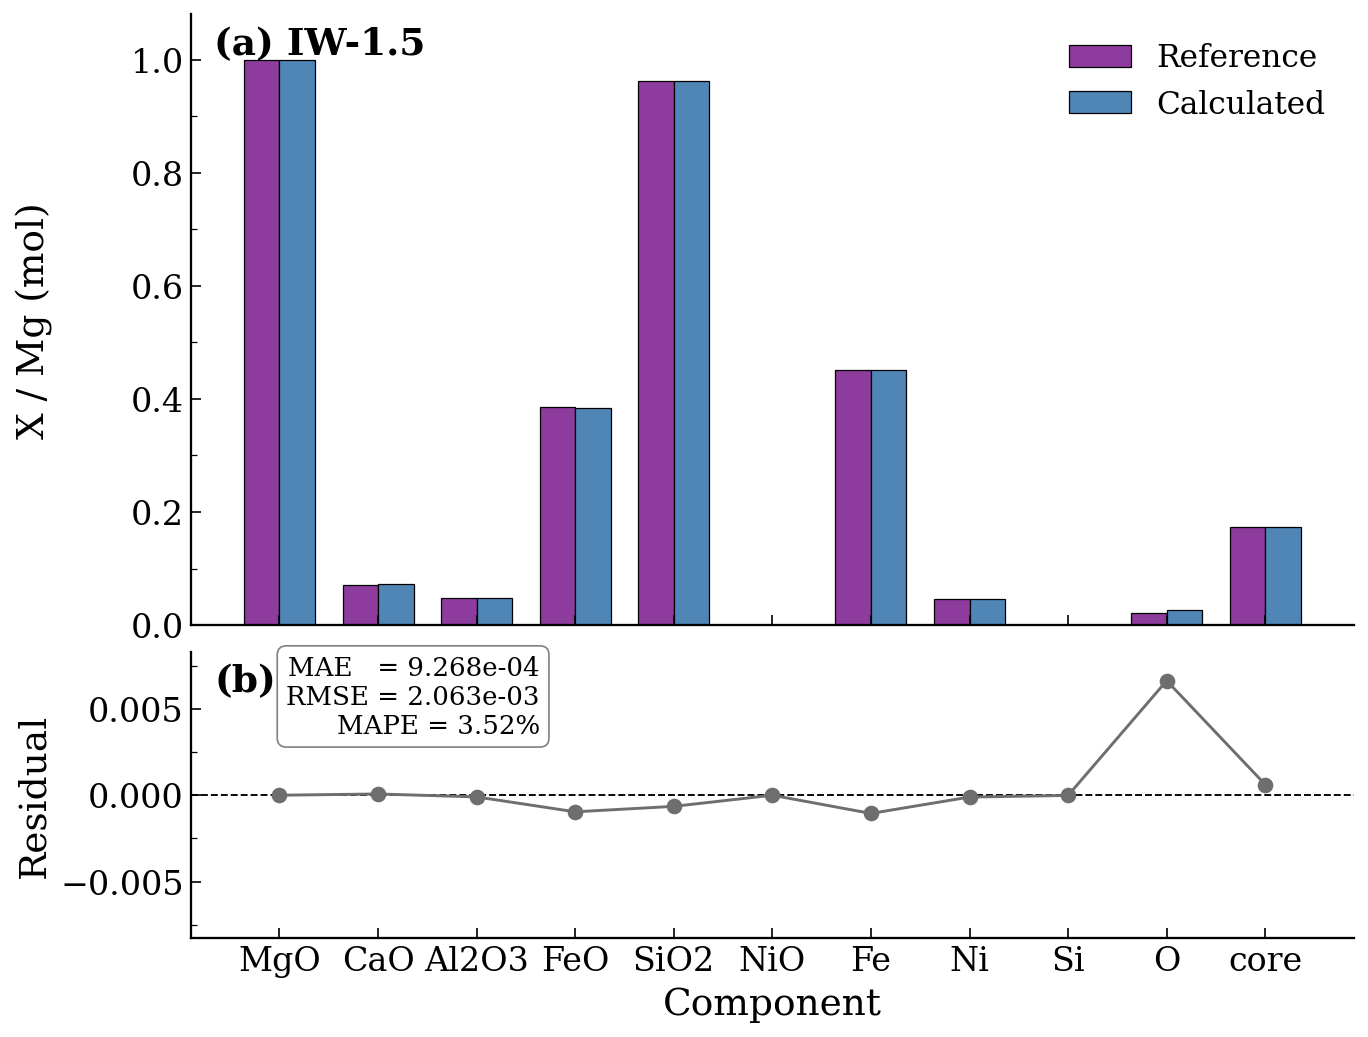

In [17]:
labels = list(ref_IW15_mol_mg.keys())
ref_IW15_values = [ref_IW15_mol_mg[label] for label in labels]
IW15_values = [IW15_bulk_mg[label] for label in labels]
plot_validation(ref_IW15_values, IW15_values, labels,
                title_suffix="IW-1.5", metrics_va_pos=0.70)

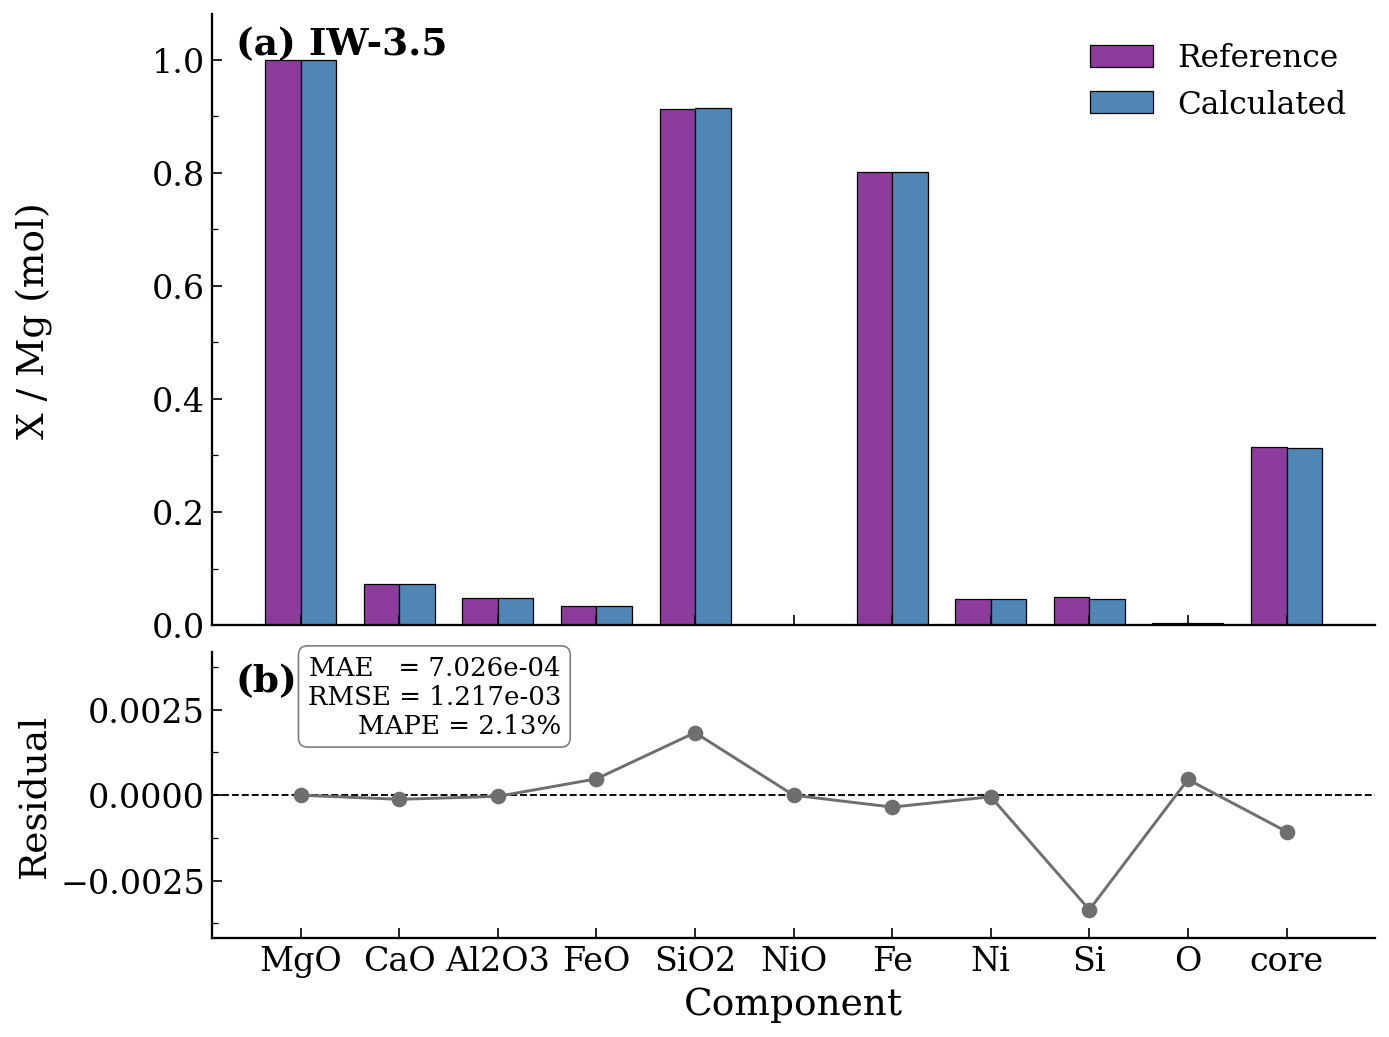

In [18]:
# ============================================================
# Validate IW-3.5: calculated vs. Fischer et al. (2017)
# ============================================================
labels_35 = list(ref_IW35_mol_mg.keys())
ref_IW35_values = [ref_IW35_mol_mg[l] for l in labels_35]
IW35_values     = [IW35_bulk_mg[l]     for l in labels_35]

plot_validation(ref_IW35_values, IW35_values, labels_35,
                title_suffix="IW-3.5", metrics_va_pos=0.70)

In [19]:
# ============================================================
# Save MgO-normalized compositions to CSV
# ============================================================
os.makedirs('./Tables', exist_ok=True)

df_bulk = pd.DataFrame({'IW15': IW15_bulk_mg, 'IW35': IW35_bulk_mg})
save_file = './Tables/A1_IW35IW15_composition.csv'
df_bulk.to_csv(save_file, index=True)

print(f"Saved to {save_file}")
df_bulk

Saved to ./Tables/A1_IW35IW15_composition.csv


,IW15,IW35
MgO,1.000000,1.000000
Al2O3,0.048755,0.048755
CaO,0.071951,0.071951
FeO,0.384392,0.033604
NiO,0.000279,0.000014
SiO2,0.961552,0.915298
Fe,0.450372,0.801160
Ni,0.046142,0.046407
Si,0.000240,0.046494
O,0.027393,0.004066
